In [2]:
import sys  
sys.path.insert(1, '../src')

from pathlib import Path
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from skimage.morphology import local_maxima

from UNet_class_and_functions import *

from tqdm.auto import tqdm
tqdm.pandas()

In [5]:
PROJECT_ROOT = Path.cwd().parent

LOGS_PATH = PROJECT_ROOT / 'logs' / 'wing_extraction_log.csv'
CROP_ROOT = PROJECT_ROOT / 'data' / 'images' / 'wing_crops'
PREDICT_ROOT = PROJECT_ROOT / 'out' / 'predict'
MODEL_DIR = PROJECT_ROOT / 'data' / 'models' / 'best_model'

print(f'Racine du projet : {PROJECT_ROOT}')
print(f'Crop root : {CROP_ROOT}')

Racine du projet : c:\Users\Jules\Documents\IEES\idmybee
Crop root : c:\Users\Jules\Documents\IEES\idmybee\data\images\wing_crops


In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model_name = "UNet_150_epoch_lr=0.001_seed=58_func=pow_param=30"
model_load = torch.load(MODEL_DIR / (model_name + '.pth'),
                        weights_only=False, map_location=device)
model_load.to(device)
model_load.eval()

UNet(
  (encoder1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (encoder2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (encoder3): DoubleConv(
    (conv): S

In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png"}

images = sorted(p for p in CROP_ROOT.rglob("*") if p.suffix.lower() in IMG_EXTS)
print(len(images), "images trouvées.")

3389 images trouvées.


In [20]:
crops_samples = pd.read_csv(LOGS_PATH)
crops_samples.head()

,name,image,status,n_detections,confidence,obb,aspect,similarity,output
0,FR15_ABOM07082020038_P1,Bombus_confusus\male\FR15_ABOM07082020038_P1.JPG,OK,4,0.772,"[[3044.8, 1980.7], [1933.3, 1980.7], [1933.2, ...",2.36,0.940,data\images\wing_crops\Bombus_confusus\male\FR...
1,FR15_ABOM07082020038_P2,Bombus_confusus\male\FR15_ABOM07082020038_P2.JPG,OK,2,0.884,"[[3040.0, 2037.8], [1928.5, 2037.8], [1928.5, ...",2.46,0.911,data\images\wing_crops\Bombus_confusus\male\FR...
2,FR15_ABOM07082020038_S1,Bombus_confusus\male\FR15_ABOM07082020038_S1.jpg,OK,2,0.860,"[[1720.7, 2098.7], [637.9, 2098.7], [637.9, 16...",2.39,0.900,data\images\wing_crops\Bombus_confusus\male\FR...
3,FR15_ABOM07082020038_S2,Bombus_confusus\male\FR15_ABOM07082020038_S2.jpg,OK,2,0.809,"[[1578.9, 2145.9], [511.9, 2145.9], [511.9, 16...",2.36,0.923,data\images\wing_crops\Bombus_confusus\male\FR...
4,FR15_ABOM07082020038_S3,Bombus_confusus\male\FR15_ABOM07082020038_S3.jpg,OK,2,0.868,"[[1626.2, 2098.7], [606.4, 2098.7], [606.4, 16...",2.33,0.897,data\images\wing_crops\Bombus_confusus\male\FR...


In [21]:
valid_samples = crops_samples.loc[crops_samples.status == 'OK']

In [ ]:
samples = []
for idx, row in valid_samples[:10].iterrows():
    samples.append(row.image)

samples

['Bombus_confusus\\male\\FR15_ABOM07082020038_P1.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_P2.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_S1.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_S2.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_S3.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_P1.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_P2.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_S1.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_S2.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_S3.jpg']

In [ ]:
sample_indices = np.random.choice(len(valid_samples), size=min(10, len(valid_samples)), replace=False)

In [24]:
crops = []
crops_t = []
out_crops = []
annotations = []
boxes = []
pathes = []

for _, row in tqdm(valid_samples.iterrows(), total=valid_samples.shape[0]): # .iloc[sample_indices].iterrows():
    pathes.append(row.image)

    crop = cv2.imread(str(CROP_ROOT / row.image))
    crop = cv2.cvtColor(crop,cv2.COLOR_BGR2RGB)
    crops.append(crop)

    crop_t = torch.Tensor(crop.transpose(2,0,1)/255).unsqueeze(0)
    crops_t.append(crop_t)

    crop_t = crop_t.to(device)
    output = model_load(crop_t).cpu().squeeze(0).detach().numpy().transpose(1,2,0)
    out_crops.append(output)

    output = output.squeeze(axis = 2)
    maximas = np.argwhere(local_maxima(output) == True)
    scores = np.array([output[pt[0],pt[1]] for pt in maximas])
    sorter = np.argsort(scores)
    maximas = maximas[sorter,:]
    maximas = maximas[-18:,:]
    annotations.append(maximas)

  0%|          | 0/3374 [00:00<?, ?it/s]

In [27]:
pathes[:10]

['Bombus_confusus\\male\\FR15_ABOM07082020038_P1.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_P2.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_S1.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_S2.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020038_S3.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_P1.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_P2.JPG',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_S1.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_S2.jpg',
 'Bombus_confusus\\male\\FR15_ABOM07082020082_S3.jpg']

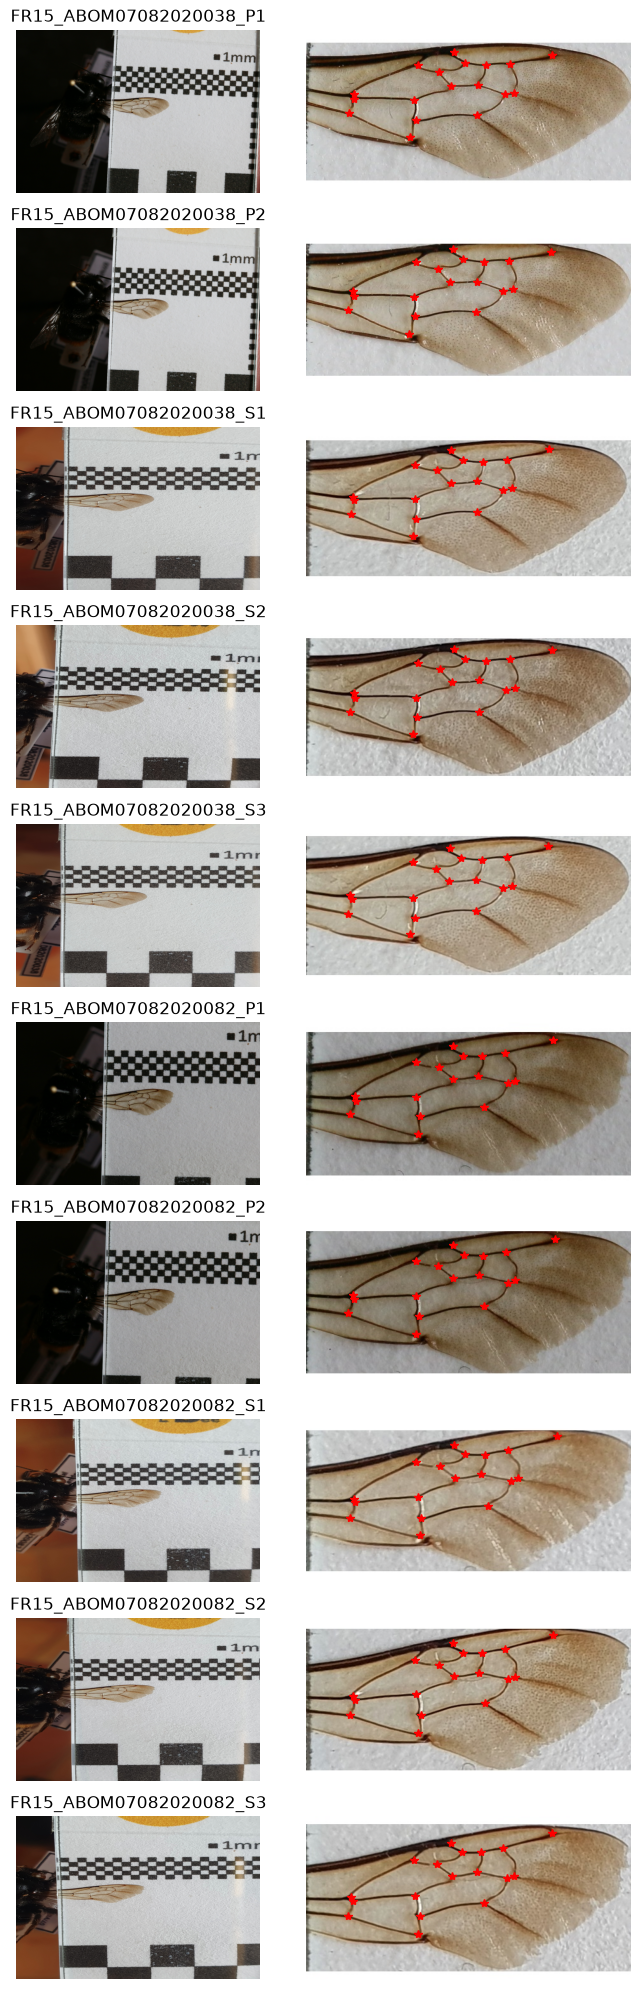

In [30]:
fig, axes = plt.subplots(10, 2, figsize=(7, 20))
if len(pathes) == 1:
    axes = axes.reshape(1, -1)

for i in range(10):
    im_id = Path(pathes[i]).stem
    wide_path = PROJECT_ROOT / 'data' / 'images' / 'organized' / pathes[i]

    image = cv2.imread(wide_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (1440, 960))

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f'{im_id}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(crops[i])
    axes[i, 1].plot(annotations[i][:,1], annotations[i][:,0],'r*')
    axes[i, 1].axis('off')

plt.tight_layout()
# plt.savefig(PREDICT_ROOT / 'UNet_predictions.png', dpi=300)
plt.show()

In [35]:
def write_tps(records: list[dict], out_path: str):
    with open(out_path, "w", encoding="utf-8") as f:
        for rec in records:
            lm = rec["landmarks"]
            f.write(f"LM={len(lm)}\n")
            for y, x in lm:
                f.write(f"{x:.4f} {y:.4f}\n")
            f.write(f"IMAGE={rec['image_path']}\n")
            f.write(f"ID={rec['specimen_id']}\n")

In [40]:
records = []

for i, (coords, img_path) in enumerate(zip(annotations, pathes)):
    records.append(
        {
            "landmarks": coords,
            "image_path": CROP_ROOT / str(img_path),
            "specimen_id": i,  # img_path.stem,
        }
    )
    print(f"{Path(img_path).name}: OK")

write_tps(records, PROJECT_ROOT / 'data/annotations/from_crops.tps')

FR15_ABOM07082020038_P1.JPG: OK
FR15_ABOM07082020038_P2.JPG: OK
FR15_ABOM07082020038_S1.jpg: OK
FR15_ABOM07082020038_S2.jpg: OK
FR15_ABOM07082020038_S3.jpg: OK
FR15_ABOM07082020082_P1.JPG: OK
FR15_ABOM07082020082_P2.JPG: OK
FR15_ABOM07082020082_S1.jpg: OK
FR15_ABOM07082020082_S2.jpg: OK
FR15_ABOM07082020082_S3.jpg: OK
FR15_ABOM080820007_P1.JPG: OK
FR15_ABOM080820007_P2.JPG: OK
FR15_ABOM080820007_S1.jpg: OK
FR15_ABOM080820007_S2.jpg: OK
FR15_ABOM080820007_S3.jpg: OK
FR15_ABOM080820039_P1.JPG: OK
FR15_ABOM080820039_P2.JPG: OK
FR15_ABOM080820039_S1.jpg: OK
FR15_ABOM080820039_S2.jpg: OK
FR15_ABOM080820039_S3.jpg: OK
FR15_ABOM090820071_P1.JPG: OK
FR15_ABOM090820071_P2.JPG: OK
FR15_ABOM090820071_S1.jpg: OK
FR15_ABOM090820071_S2.jpg: OK
FR15_ABOM090820071_S3.jpg: OK
FR15_ABOM14080820006_P1.JPG: OK
FR15_ABOM14080820006_P2.JPG: OK
FR15_ABOM14080820006_S1.jpg: OK
FR15_ABOM14080820006_S2.jpg: OK
FR15_ABOM14080820006_S3.jpg: OK
FR15_ABOM170820009_P1.JPG: OK
FR15_ABOM170820009_P2.JPG: OK
FR15_ABOM1